# Training Large Language Models (LLMs)

## Motivation: Why LLM Training Exists
- Traditional ML paradigm:
  - One model per task  
    - Spam detection → separate model  
    - Sentiment analysis → separate model
- Key observation:
  - These tasks are **not disjoint**
  - All require **language understanding**

### Transfer Learning (Core Idea)
- Train a model once on massive data
- Reuse learned knowledge across tasks
- Fine-tune instead of training from scratch
- **Fundamental paradigm behind LLMs**

---

## Two-Stage Training Framework

### 1. Pre-training (Most Expensive Stage)
- Goal:
  - Learn structure of **language + code**
- Model type:
  - Text-to-text
  - Mostly **decoder-only Transformers** (≈90%)
- Objective:
  - **Next-token prediction**
- Trained on **unlabeled web-scale data**

$$
\mathcal{L}_{\text{pretrain}} = - \sum_{t=1}^{T} \log P(x_t \mid x_1, \dots, x_{t-1})
$$

---

### 2. Tuning (Adaptation Stage)
- Start from pre-trained weights
- Adapt model to specific tasks:
  - Spam detection
  - Sentiment analysis
  - Classification
  - Chat / instruction following
- Much cheaper than pre-training

---

## Pre-training Data

### Common Data Sources
- **Common Crawl**
  - ~3 billion web pages per month
- Wikipedia
- Reddit conversations
- Social media text
- GitHub repositories (code)
- Stack Overflow
- Technical forums and blogs

---

## Scale of Training Data
- Measured in **number of tokens**
- Typical scale:
  - Hundreds of billions → trillions → tens of trillions

### Examples
- **GPT-3** → ~300B tokens  
- **LLaMA-3** → ~15T tokens  

---

## Compute Notations (Very Important)

### 1. FLOPs — Floating Point Operations
- Measures **total computation required**
- Used to estimate **training cost**

$$
\text{Training FLOPs} \approx 6 \times N_{\text{params}} \times N_{\text{tokens}}
$$

Where:
- $(N_{\text{params}}$) = number of model parameters  
- $(N_{\text{tokens}}$) = number of training tokens  

**Order of magnitude**
$$
\text{LLM Training} \approx 10^{25} \text{ FLOPs}
$$

- Exact value depends on architecture:
  - Dense models
  - MoE models (lower active FLOPs)

---

### 2. FLOPS — Floating Point Operations per Second
- Measures **hardware speed**
- Indicates how fast GPUs/TPUs can execute FLOPs

$$
\text{Training Time} = \frac{\text{Total FLOPs}}{\text{FLOPS}}
$$

⚠️ **Important**
- FLOPs = total work  
- FLOPS = speed  
- Papers may mix notation → rely on context

---

## Why Pre-training Is So Expensive
- Trillions of training tokens
- Hundreds of billions of parameters
- Long training runs
- Large GPU clusters

**Architecture impact**
- Dense models → all parameters active
- MoE models → partial activation → lower compute per step

---

## Key Takeaways
- LLM training is built on **transfer learning**
- Pre-training dominates cost and compute
- Data scale is **trillions of tokens**
- Compute understanding requires:
  - **FLOPs** → total work
  - **FLOPS** → hardware speed


## Scaling Laws for Language Models

### Why Scaling Laws Matter
- Pre-training is extremely expensive:
  - Huge models
  - Massive datasets
  - Limited compute budgets
- Key question:
  > How does performance change as we scale **model size**, **data size**, and **compute**?

---

## Scaling Laws (Kaplan et al., 2020)
**Paper:** *Scaling Laws for Neural Language Models*

### Experimental Setup
- Trained many Transformer-based LMs
- Varied:
  - Model size (number of parameters)
  - Dataset size (number of tokens)
  - Compute budget
- Objective:
  - **Next-token prediction loss**

### Key Findings
- Performance improves predictably with:
  - Larger models
  - More data
  - More compute
- Loss follows a **power-law relationship** with scale

$$
\mathcal{L} \propto N^{-\alpha}
$$

Where:
- $(N$) = model size, data size, or compute
- $(\alpha$) = scaling exponent

---

## Sample Efficiency
- Larger models are **more sample efficient**
- Meaning:
  - For the same number of training tokens,
    - Larger models achieve **lower loss**
- Result:
  - Bigger models learn faster **per token**

---

## Fixed Compute Problem
- Compute is **not unlimited**
- Given a fixed compute budget:
  - How big should the model be?
  - How much data should we train on?

---

## Chinchilla Law (DeepMind, 2022)

### Core Insight
- Many large models (e.g. GPT-3) were **undertrained**
- Optimal training requires **more data**, not just larger models

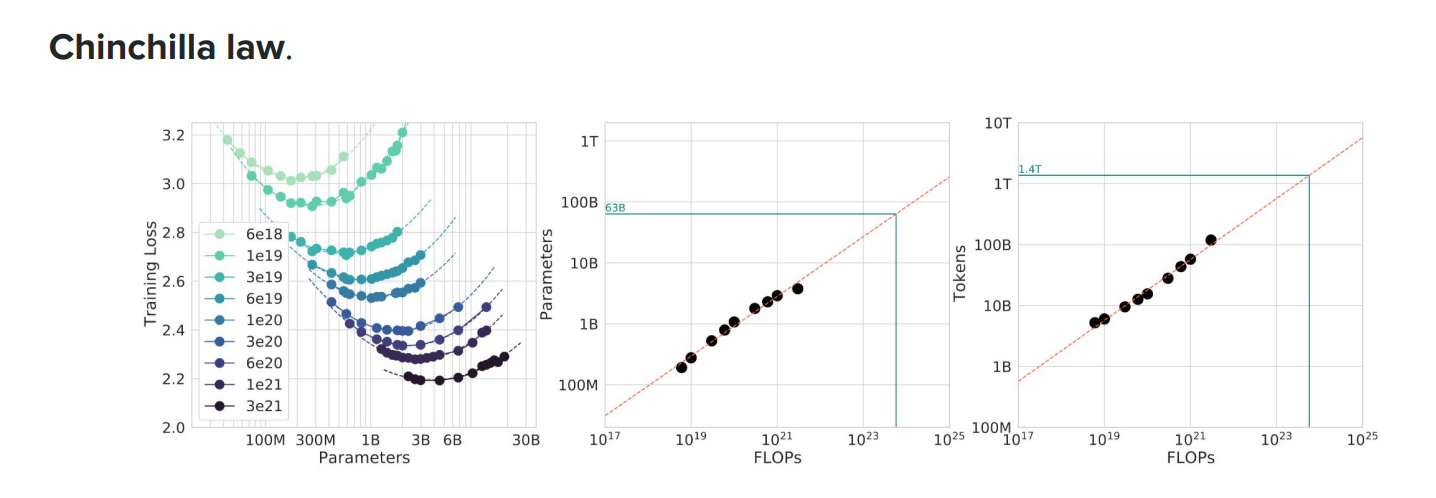

### Optimal Compute Allocation
$$
N_{\text{tokens}} \approx 20 \times N_{\text{parameters}}
$$

Where:
- $(N_{\text{parameters}}$) = number of model parameters
- $(N_{\text{tokens}}$) = number of training tokens

---

### Interpretation
- If model is too large and data too small → **undertrained**
- If data is large but model is too small → **capacity-limited**
- Optimal point balances **model size + data size**
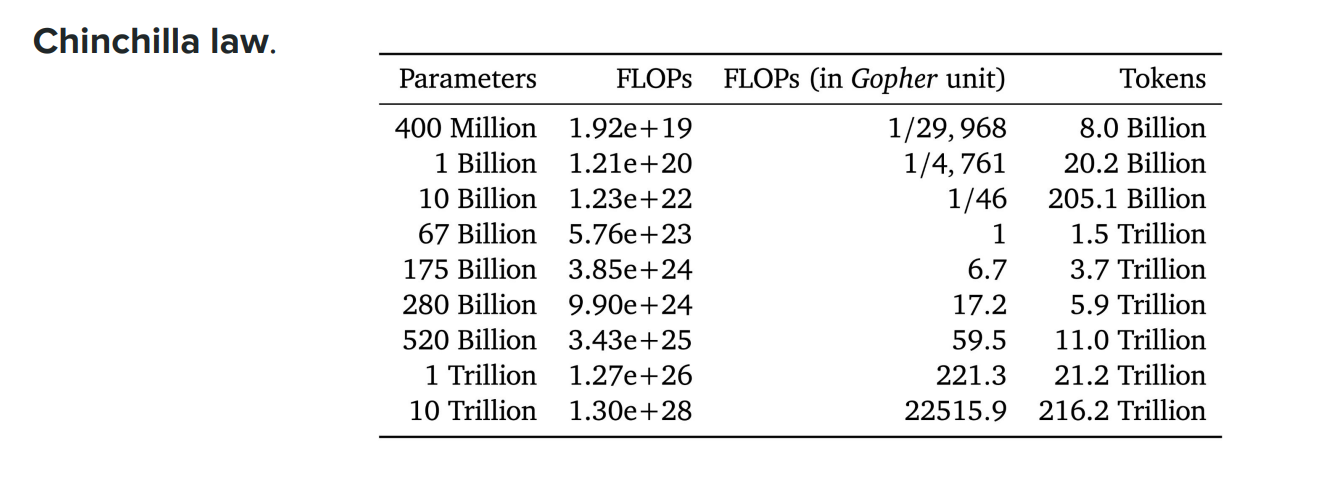
---

### Example: GPT-3
- Parameters: ~175B
- Tokens: ~300B
- According to Chinchilla:
  - Should have used **~3.5T tokens**
- Conclusion:
  - GPT-3 was **compute-inefficient**

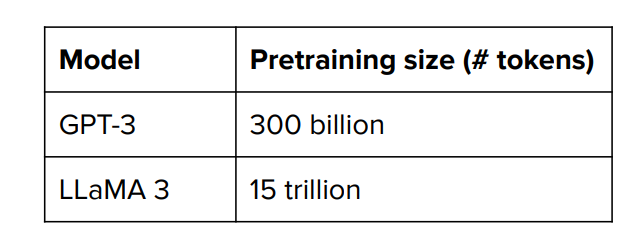 

---

## Architecture Assumptions
- Scaling laws assume:
  - Transformer-based
  - Decoder-only
- Architecture choice matters **less** than:
  - Model size
  - Data size
  - Compute budget

---

## Challenges of Pre-training

### 1. Cost
- Training cost:
  - Millions → tens of millions → hundreds of millions USD
- Requires:
  - Large GPU clusters
  - Long training runs

---

### 2. Environmental Impact
- High energy consumption
- Carbon footprint increasingly reported in papers

---

### 3. Knowledge Cutoff
- Model only learns from data **available before training ends**
- Cannot natively know:
  - New events
  - New research
  - New facts

📌 **Knowledge Cutoff Date**
- Explicitly mentioned in model cards
- Example:
  - GPT-5 → Knowledge cutoff: *September 30*
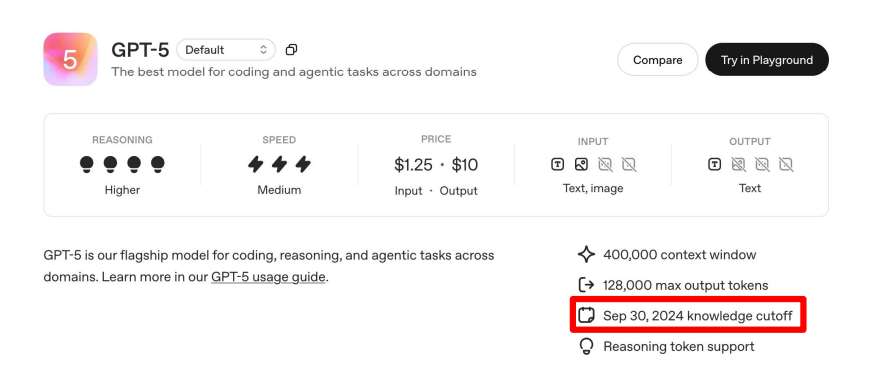
---

### 4. Knowledge Editing Is Hard
- Updating weights post-training can:
  - Break other knowledge
  - Cause regressions
- No clean, safe way to edit knowledge in-place

---

### 5. Memorization & Plagiarism
- Risk:
  - Model reproduces training data verbatim
- Especially problematic for:
  - Private data
  - Copyrighted content

---

## Key Takeaways
- Scaling improves performance predictably
- Bigger models are more sample efficient
- Compute is the real bottleneck
- **Chinchilla Law**:
  - Data matters as much as parameters
- Pre-training introduces:
  - Cost
  - Environmental concerns
  - Knowledge cutoff limitations


## How Are Large Language Models Trained in Practice?

### Why Training Is Hard
- LLMs have:
  - Billions → hundreds of billions of parameters
  - Trillions of training tokens
- Training involves **massive matrix multiplications**
- Hardware that excels at this:
  - **GPUs** (or TPUs at Google)

---

## Training Pipeline of an LLM

### 1. Model Initialization
- Decoder-only Transformer
- Parameters:
  - $(10^9$) → $(10^{11+}$)
- Randomly initialized before training

---

## Core Training Steps

### 1️⃣ Forward Pass
- Input:
  - Batch of token sequences
- Operations:
  - Embedding lookup
  - Self-attention
  - Feedforward layers
- Output:
  - Next-token probability distribution
- Compute **training loss**

$$
\mathcal{L} = -\sum_{t=1}^{T} \log P(x_t \mid x_1, \dots, x_{t-1})
$$

---

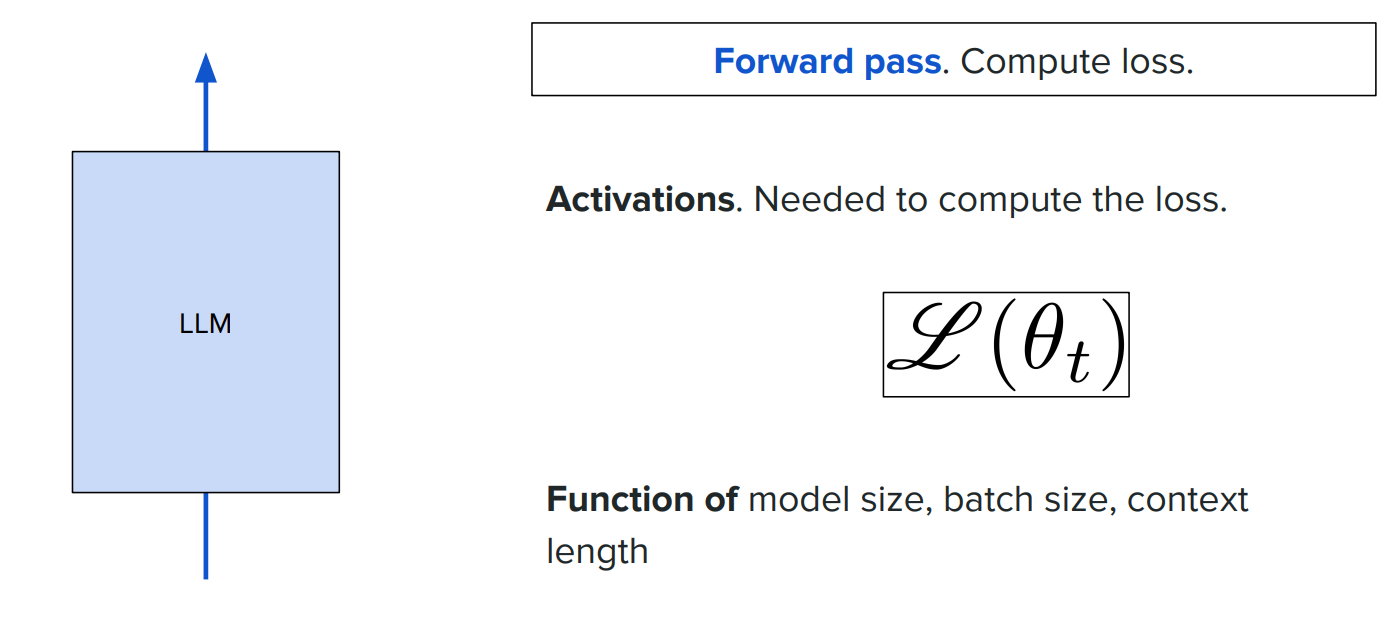


---
---

### Activations (Very Important)
- Activations = intermediate layer outputs
- Must be **stored in memory**
- Needed for backpropagation

#### Activation memory depends on:
- Model size
- Batch size
- Context length
- Self-attention complexity

$$
\text{Attention Complexity} = O(N^2)
$$

Where:
- $(N$) = sequence length

---

### 2️⃣ Backward Pass (Backpropagation)
- Compute gradients of loss w.r.t. parameters

$$
\nabla_\theta \mathcal{L}
$$

- Gradients must be stored in memory

---

---

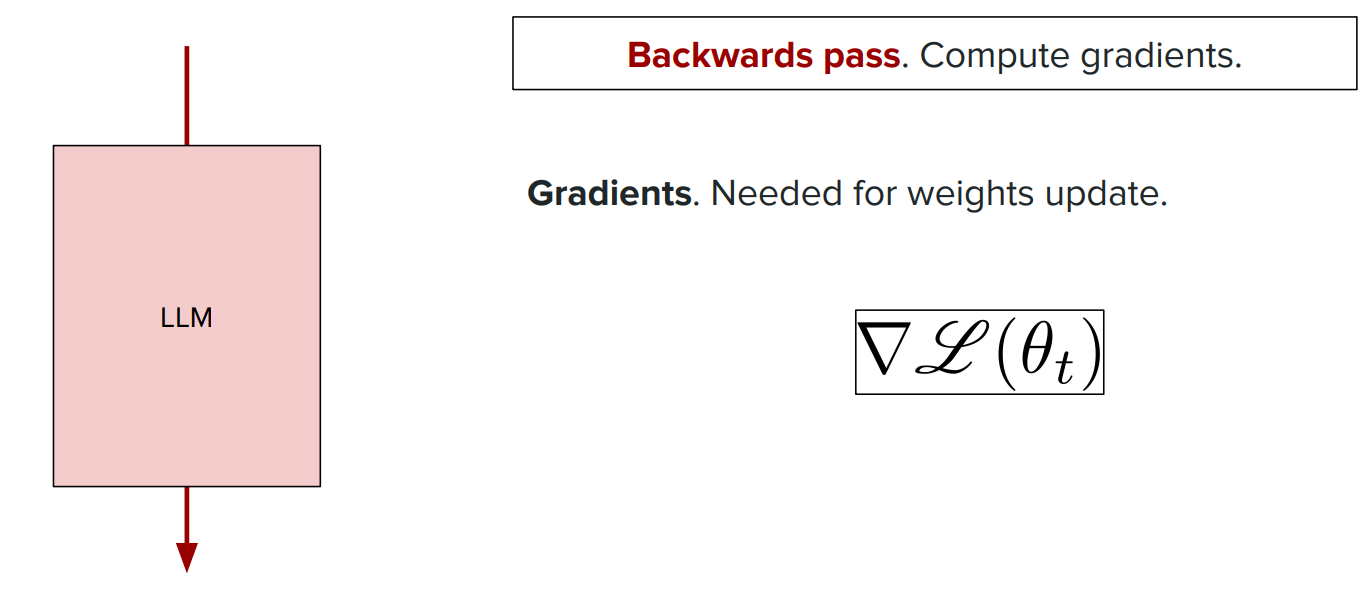

---

### 3️⃣ Weight Update
- Update parameters using an optimizer

#### Adam Optimizer (Common)
Maintains:
- First moment (mean of gradients)
- Second moment (mean of squared gradients)

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t
$$
$$
v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2
$$

- These optimizer states also consume **memory**

---

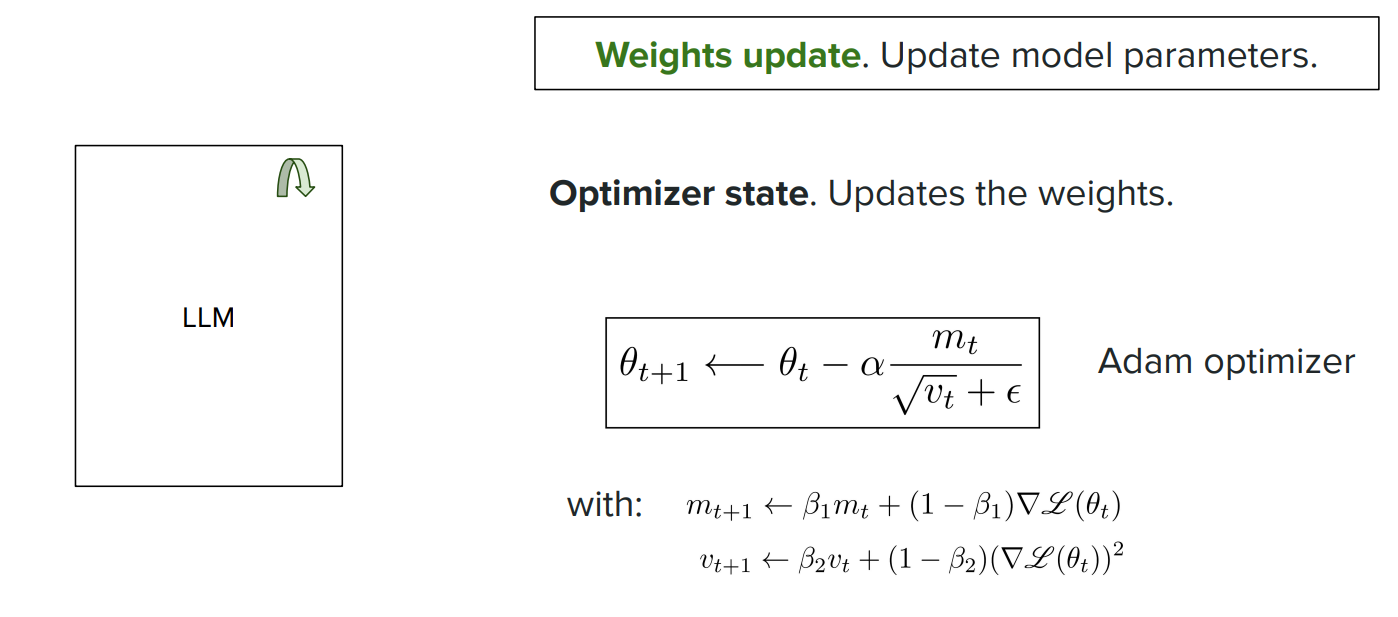

---

## What Must Be Stored in GPU Memory?

For **each parameter**:
- Model weights
- Gradients
- Optimizer states (Adam: 2 extra tensors)

For **each layer & token**:
- Activations

👉 Memory grows very fast.

---

## GPU Memory Is Limited

### Example: NVIDIA H100
- GPU Memory ≈ **80 GB**
- Sounds large ❌
- Insufficient for:
  - Full model
  - Gradients
  - Optimizer states
  - Activations

---

## Memory Bottleneck Summary

| Component | Memory Cost |
|---------|------------|
| Parameters | High |
| Gradients | High |
| Optimizer states | Very high |
| Activations | Extremely high |

📌 **Memory, not compute, is often the bottleneck**

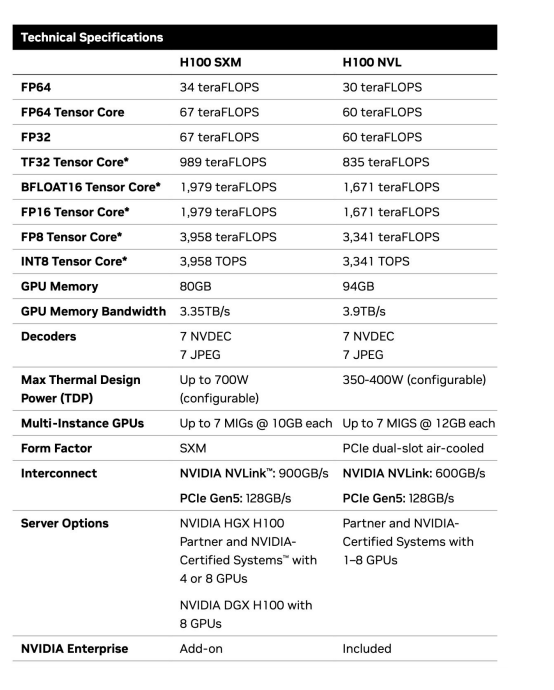

---

## Key Problem
> How do we train such large models if **one GPU cannot hold everything**?

### Solution
- Use **multiple GPUs**
- **Distribute**:
  - Model
  - Data
  - Computation

➡️ Leads to **distributed training strategies**

*(Next section: Data Parallelism, Model Parallelism, Pipeline Parallelism, ZeRO)*

---

## Key Takeaways
- Training involves:
  - Forward pass
  - Backward pass
  - Weight updates
- Memory requirements dominate
- GPU memory is limited
- Single GPU is insufficient
- Distributed training is **mandatory** for LLMs


## Distributed Training Strategies for LLMs

Large Language Models (LLMs) **cannot be trained on a single GPU** because:
- Model parameters are extremely large (billions to hundreds of billions)
- Activations scale with:
  - Batch size
  - Sequence length
  - Number of layers
- Optimizer states multiply memory usage

Hence, **distributed training across multiple GPUs is mandatory**.

---

## 1️⃣ Data Parallelism (DP)

### Core Idea
- Each GPU holds a **full replica of the model**
- Training data is **split across GPUs**
- Each GPU performs:
  - Forward pass
  - Loss computation
  - Backward pass

---

### Detailed Workflow
Let there be **N GPUs**.

1. Global batch size $( B $) is split:
$$
B = \sum_{i=1}^{N} B_i
$$

2. Each GPU computes gradients independently:
$$
\nabla \mathcal{L}_i = \frac{\partial \mathcal{L}_i}{\partial \theta}
$$

3. Gradients are **synchronized (All-Reduce)**:
$$
\nabla \mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \nabla \mathcal{L}_i
$$

4. Each GPU applies the **same weight update**

---

### What Is Replicated on Each GPU
- Model parameters
- Activations
- Gradients
- Optimizer states (Adam moments)

➡️ **Heavy memory duplication**

---

### Advantages
- Simple conceptual model
- Easy to scale batch size
- Widely supported in frameworks (PyTorch DDP, Horovod)

---

### Limitations
- ❌ Entire model **must fit on one GPU**
- ❌ Memory grows linearly with model size
- ❌ Communication overhead from gradient synchronization
- ❌ Inefficient for very large models

---

## ZeRO: Zero Redundancy Optimizer

### Motivation
In standard Data Parallelism:
- Every GPU stores **identical copies** of:
  - Parameters
  - Gradients
  - Optimizer states

This leads to **massive memory waste**.

---

### Core Idea
**Shard (partition) training states across GPUs**  
instead of duplicating them.

---

### ZeRO Stage 1 — Optimizer State Partitioning

- Optimizer states (Adam moments) are sharded
- Parameters and gradients are still replicated

Memory per GPU:
$$
\text{Params} + \text{Grads} + \frac{1}{N}(\text{Optimizer States})
$$

📉 Memory reduction ≈ **2×**

---

### ZeRO Stage 2 — Gradient Partitioning

- Shard:
  - Optimizer states
  - Gradients
- Parameters still replicated

Memory per GPU:
$$
\text{Params} + \frac{1}{N}(\text{Grads} + \text{Optimizer States})
$$

📉 Memory reduction ≈ **4×**

---

### ZeRO Stage 3 — Parameter Partitioning

- Shard:
  - Parameters
  - Gradients
  - Optimizer states
- **No redundant copies**

Memory per GPU:
$$
\frac{1}{N}(\text{Params} + \text{Grads} + \text{Optimizer States})
$$

📉 Maximum memory savings  
❌ Highest communication overhead

---

### Communication Trade-off
- Higher ZeRO stage → more parameter gathering
- Frequent all-gather and reduce-scatter operations
- Slower step time but enables much larger models

---

## 2️⃣ Model Parallelism (MP)

### Core Idea
Instead of splitting data, **split the model itself** across GPUs.

Used when:
- Model parameters cannot fit on a single GPU
- Activation memory is too large

---

### a) Tensor Parallelism

- Split **large matrix operations**
- Example: Linear layer
$$
Y = XW
$$

If $( W \in \mathbb{R}^{d \times d} $), split across GPUs:
- Column-wise or row-wise partition

Each GPU computes a partial result, then aggregates

Benefits:
- Reduces memory per GPU
- Reduces per-GPU compute

Used in:
- Megatron-LM
- DeepSpeed
- Most large LLMs

---

### b) Pipeline Parallelism

- Split model **by layers**
- Each GPU handles a subset of layers

Example:
- GPU 1 → Layers 1–4
- GPU 2 → Layers 5–8
- GPU 3 → Layers 9–12

Activations are passed between GPUs.

---

#### Pipeline Challenges
- Pipeline bubbles (idle GPUs)
- Requires micro-batching to improve utilization
- Adds latency

---

### c) Expert Parallelism (MoE Models)

- Used in **Mixture-of-Experts (MoE)** LLMs
- Each expert FFN placed on different GPUs
- Router sends tokens to experts dynamically

Only selected experts are active per token.

Used in:
- Switch Transformer
- Mixtral
- DeepSeek
- GShard

---

## Key Observation 

- Data Parallelism → scales **data**
- ZeRO → removes **memory redundancy**
- Model Parallelism → splits **model computation**

These techniques are **composable** and almost always used together in practice.


## Flash Attention (Exact Attention Optimization)

Flash Attention is an **exact attention algorithm** introduced in **2022 (Stanford)**.
It **does not approximate attention** — it computes the *same result* as standard
self-attention, but **much faster and with far less memory usage**.

The key idea is to **exploit GPU memory hierarchy**.

---

## GPU Memory Hierarchy (Why Flash Attention Exists)

GPUs have **two very different memory types**:

### 1️⃣ HBM (High Bandwidth Memory)
- Large (≈ tens of GB, e.g., 80 GB on H100)
- Relatively **slow**
- Bandwidth: ~1–3 TB/s
- This is what we usually call *GPU memory*

### 2️⃣ SRAM (On-chip Memory)
- Very small (≈ tens of MB)
- **Extremely fast**
- Bandwidth: ~10–20+ TB/s
- Located next to compute units

⚠️ **Key bottleneck**:  
Modern GPUs are **memory-bound**, not compute-bound.  
Most time is spent **reading/writing HBM**, not computing FLOPs.

---

## Standard Self-Attention (Vanilla Implementation)

Self-attention formula:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d}}\right)V
$$

Where:
- $( Q \in \mathbb{R}^{N \times d} $)
- $( K \in \mathbb{R}^{N \times d} $)
- $( V \in \mathbb{R}^{N \times d} $)
- $( N $) = sequence length

---

### Naive Attention Memory Pattern

1. Load $( Q, K $) from **HBM**
2. Compute $( QK^T $) → store to **HBM**
3. Read $( QK^T $) from **HBM**
4. Apply softmax → write to **HBM**
5. Read softmax result + $( V $) from **HBM**
6. Multiply → write output to **HBM**

❌ **Multiple HBM reads/writes**
❌ Massive memory traffic
❌ GPU compute units stay idle waiting for memory

---

## Key Insight Behind Flash Attention

### Softmax Is Row-wise

For a row vector $( x $):

$$
\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}
$$

Important property:
- Softmax **can be computed incrementally**
- You do **not need the full matrix at once**

---

## Flash Attention Core Idea

👉 **Tile (block) the computation** so that:

- Small blocks fit into **SRAM**
- Entire attention computation for a block is done **end-to-end**
- Minimize reads/writes to **HBM**

This technique is called **tiling**.

---

## Flash Attention Algorithm (High-Level)

For each **query block** $( Q_i $):
1. Load a small block of $( Q_i $) into **SRAM**
2. Loop over key/value blocks $( (K_j, V_j) $):
   - Load $( K_j, V_j $) into SRAM
   - Compute partial attention scores
   - Update softmax statistics **incrementally**
3. Accumulate final output
4. Write output once to **HBM**

✅ One HBM write per output  
✅ No intermediate matrices stored in HBM

---

## Incremental Softmax Trick (Key Formula)

Let attention scores be split into blocks:

$$
S = [S_1, S_2, \dots, S_n]
$$

Instead of computing:
$$
\text{softmax}(S) = \frac{e^{S}}{\sum e^{S}}
$$

We maintain per-row:
- Running maximum $( m $)
- Running normalization factor $( l $)

Update rule (conceptual):
$$
m_{\text{new}} = \max(m_{\text{old}}, \max(S_i))
$$

$$
l_{\text{new}} = e^{m_{\text{old}} - m_{\text{new}}} \cdot l_{\text{old}} + \sum e^{S_i - m_{\text{new}}}
$$

This allows **exact softmax computation block-by-block**.

📌 No approximation — mathematically identical to full softmax.

---

## Why This Is Faster

| Aspect | Vanilla Attention | Flash Attention |
|------|------------------|----------------|
| HBM Reads/Writes | Very High | Minimal |
| SRAM Usage | Minimal | Heavy |
| FLOPs | Same | Same |
| Runtime | Slow | Much Faster |

Flash Attention is **IO-aware**, not FLOP-aware.

---

## Backward Pass Optimization (Recomputation)

### Standard Training
- Store **activations** during forward pass
- Use them during backward pass
- Activation memory dominates GPU usage

---

### Flash Attention Trick
- **Do not store activations**
- Recompute them during backward pass
- Recompute is cheap due to:
  - SRAM locality
  - Fast kernels

This is called **activation recomputation (checkpointing)**.

---

## Counterintuitive Result

Even though:
- More FLOPs are executed (recomputation)

We get:
- **Less runtime**
- **Much less memory usage**

Example from paper:
- HBM reads reduced by ~10×
- Runtime reduced
- Training fits larger batch sizes / longer context

---

## Key Properties of Flash Attention

- ✅ Exact attention (no approximation)
- ✅ Lower memory footprint
- ✅ Faster forward + backward pass
- ✅ Enables longer context lengths
- ✅ Widely used in modern LLMs

---

## Practical Notes

- Flash Attention v1, v2, v3:
  - Hardware-specific optimizations
  - Adapted to newer GPUs (A100, H100)
- Used in:
  - PyTorch
  - Triton
  - xFormers
  - Most modern LLM stacks

---

## Final Mental Model

> Flash Attention **does not change what attention computes**  
> It changes **where and how** the computation happens.

Compute in **SRAM**, not **HBM**.


## Quantization: Reducing Precision for Efficient LLM Training & Inference

Large Language Models store **all parameters, activations, gradients, and optimizer states**
as **floating-point numbers**.

A natural question arises:

> Do we really need *that much numerical precision* to achieve good performance?

Quantization addresses this question.

---

## What Is Quantization?

**Quantization** is the process of converting numbers from:
- **Higher precision** → **Lower precision**

Goal:
- Reduce **memory usage**
- Increase **compute throughput**
- Preserve **model quality** as much as possible

---

## Floating Point Numbers: How They Are Represented

A floating-point number is stored as **bits**, split into three components:

| Component | Role |
|---------|-----|
| Sign | Positive / Negative |
| Exponent | Scale of the number |
| Mantissa (Significand) | Precision / granularity |

Different floating-point formats allocate bits differently.

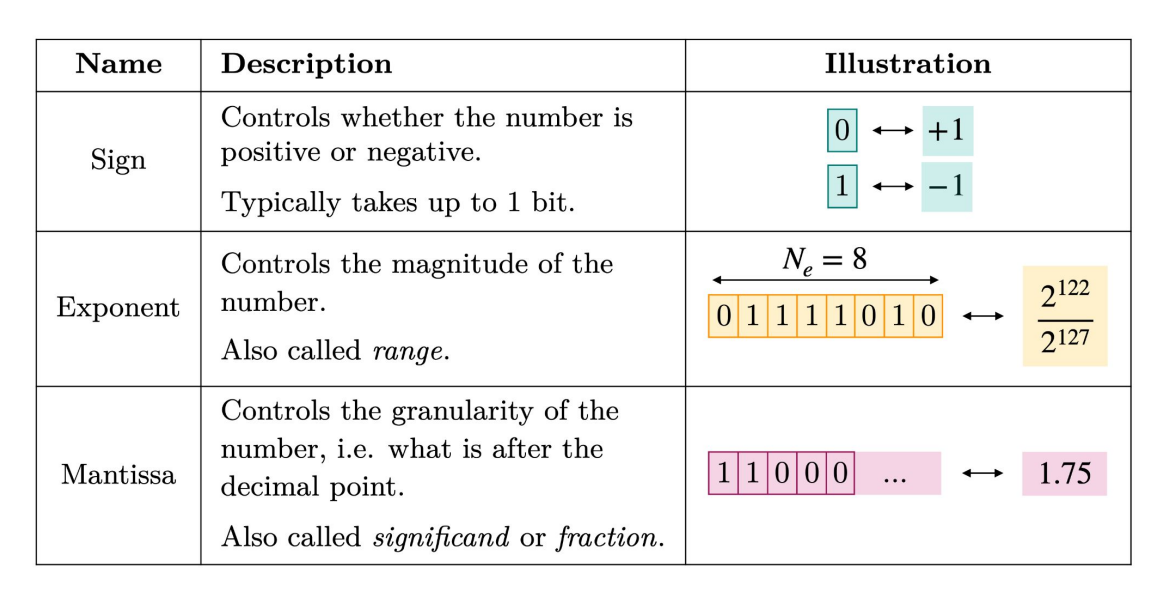

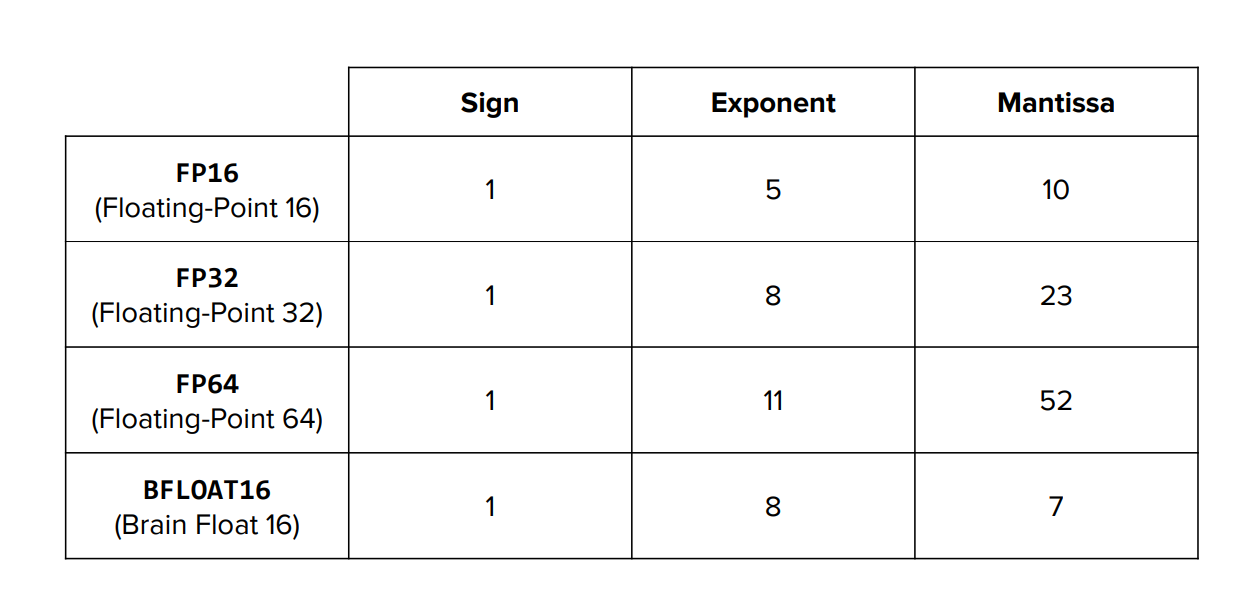

---

## Common Floating-Point Formats

| Format | Total Bits | Exponent Bits | Mantissa Bits | Notes |
|-----|-----------|--------------|---------------|------|
| FP64 (double) | 64 | 11 | 52 | Very high precision, slow |
| FP32 (single) | 32 | 8 | 23 | Standard training precision |
| FP16 (half) | 16 | 5 | 10 | Faster, less precise |
| bfloat16 | 16 | 8 | 7 | Better range, less precision |

📌 **Key observation**  
FP16 / bfloat16 use **half the memory** of FP32.

---

## Why Lower Precision Helps

### 1️⃣ Memory Savings
- FP32 → 4 bytes per value
- FP16 / bfloat16 → 2 bytes per value

This affects:
- Model parameters
- Activations
- Gradients
- Optimizer states

Result:
- Larger batch sizes
- Longer context lengths
- Bigger models per GPU

---

### 2️⃣ Compute Speed Improvements

GPUs are optimized for **lower precision arithmetic**.

Example (NVIDIA H100, approximate):

| Precision | Peak Compute |
|---------|-------------|
| FP64 | ~34 TFLOPS |
| FP32 | ~60 TFLOPS |
| FP16 / BF16 | ~1,000+ TFLOPS |
| INT8 | Even higher |

📌 Lower precision = **higher throughput**

---

## Precision vs Accuracy Trade-off

Lower precision:
- ❌ Less granularity
- ❌ More numerical noise

But:
- Neural networks are **robust to noise**
- Most LLM training works well in FP16 / BF16

This makes quantization practical.

---

## Mixed Precision Training

Modern LLMs **do not use a single precision everywhere**.

Instead, they use **mixed precision**:

- Weights: FP16 / BF16
- Activations: FP16 / BF16
- Gradients: FP16 / BF16
- Accumulators & loss scaling: FP32

---

### Loss Scaling (Why It’s Needed)

FP16 has limited precision → small gradients may underflow.

Solution:
- Multiply loss by a scale factor $( s $)
- Compute gradients
- Divide gradients by $( s $)

This preserves gradient signal.

---

## Quantization Beyond FP16

Quantization can go even further:

### Integer Quantization
- INT8
- INT4
- Even INT2 (research)

General idea:
$$
x_q = \text{round}\left(\frac{x}{\Delta}\right)
$$
Where:
- $( x $) = original value
- $( \Delta $) = quantization scale

---

### Types of Quantization

| Type | Description |
|----|------------|
| Post-Training Quantization | Quantize after training |
| Quantization-Aware Training | Simulate quantization during training |
| Weight-only Quantization | Only weights are quantized |
| Activation Quantization | Weights + activations |

---

## Where Quantization Is Used

### Training
- FP16 / BF16 mixed precision
- Saves memory + speeds training

### Inference
- INT8 / INT4 common
- Huge memory savings
- Faster decoding
- Enables deployment on smaller GPUs

---

## Why Quantization Works Well for LLMs

- Transformers are **overparameterized**
- Small numerical errors do not significantly affect predictions
- Attention + FFNs tolerate noise

📌 Performance drop is often **minimal or negligible**

---

## Practical Takeaways

- Quantization reduces **memory + compute**
- FP16 / BF16 is standard for LLM training
- Lower-bit quantization is crucial for inference
- Hardware is explicitly optimized for low precision

---

## Mental Model

> Quantization trades **numerical precision** for **efficiency**  
> and LLMs are robust enough to handle it.


## Mixed Precision Training

### Motivation
LLMs involve:
- Massive models
- Huge datasets
- Extremely high memory and compute costs

Key question:
> Can we use **lower numerical precision** without hurting model performance?

Mixed precision training is the answer.

---

## Core Idea

**Use different floating-point precisions for different parts of training**:

- **Weights** → High precision (**FP32**)
- **Forward pass** → Lower precision (**FP16 / BF16**)
- **Backward pass** → Lower precision (**FP16 / BF16**)
- **Weight updates** → High precision (**FP32**)

This allows:
- Faster computation
- Lower memory usage
- Minimal performance degradation

---

## Standard Mixed Precision Workflow

1. **Model weights stored in FP32**
2. Inputs and activations computed in FP16
3. Gradients computed in FP16
4. Gradients are accumulated and applied to **FP32 weights**
5. Updated FP32 weights are used in next iteration

---

## Why Keep Weights in FP32?

Intuition:

- **Forward / backward computations**
  - Operate on data batches
  - Data itself is noisy
  - Extreme numerical precision is not critical

- **Weights**
  - Accumulate updates over millions of steps
  - Quantization errors can **accumulate**
  - FP32 prevents long-term numerical drift

> Think of gradients as *directional hints*  
> Think of weights as *long-term memory*

---

## Benefits of Mixed Precision Training

### 1️⃣ Memory Savings
- FP16 uses **half the memory** of FP32
- Enables:
  - Larger batch sizes
  - Longer context lengths
  - Larger models per GPU

---

### 2️⃣ Faster Training
- GPUs are optimized for FP16 / BF16
- Much higher throughput than FP32
- Especially effective on modern GPUs (A100, H100)

---

### 3️⃣ Minimal Performance Loss
- Empirically shown:
  - Little to no degradation in final model quality
- Widely adopted in production LLM training

---

## Loss Scaling (Important Detail)

Problem:
- FP16 has limited dynamic range
- Small gradients may **underflow to zero**

Solution: **Loss Scaling**

1. Multiply loss by a scaling factor $( s $)
2. Compute gradients
3. Divide gradients by $( s $) before update

This preserves gradient signal.

---

## Do We Apply Mixed Precision Everywhere?

Short answer: **Not always**

- Some layers are more sensitive to precision:
  - LayerNorm
  - Softmax
  - Attention score computation

Different setups may:
- Keep some operations in FP32
- Use BF16 instead of FP16 for stability

There is **no single universal recipe**.

---

## Relationship to Scaling Laws

Mixed precision is **orthogonal** to:
- Model size vs token size tradeoffs
- Chinchilla-style scaling laws

In practice:
- Teams run **small-scale experiments**
- Determine:
  - Optimal precision
  - Optimal model size
  - Optimal dataset size
- Then extrapolate to large-scale training

---

## Practical Notes

- FP16 and BF16 are the most common choices
- BF16 has:
  - Wider exponent range
  - Better numerical stability
- Many modern LLMs prefer **BF16**

---

## Key Takeaway

Mixed precision training:
- Reduces memory
- Speeds up training
- Preserves model quality

It is a **core technique** in modern LLM training pipelines.


## Supervised Fine-Tuning (SFT)

### Why Pre-training Is Not Enough
- Pre-training teaches the model:
  - Grammar
  - Syntax
  - Broad world patterns
- But **not helpful behavior**

Example:
> *“Can I put my teddy bear in the washer?”*

A pre-trained LLM:
- Predicts likely next tokens
- Does **not reason as an assistant**
- Mimics patterns from internet text

❌ Not helpful  
❌ Not aligned with user intent

---

## Motivation for Fine-Tuning
Goal:
- Turn a **next-token predictor**
- Into a **helpful assistant**

This is achieved via **Supervised Fine-Tuning (SFT)**.

---

## What Is SFT?

**SFT = Supervised Fine-Tuning**

- Start from **pre-trained weights**
- Train on **(input, output)** pairs
- Objective:
  - Produce *useful, human-like responses*
- Supervised = labeled data

---

## Nature of SFT Data

Each training example contains:

- **Input (prompt)**  
- **Target output (ideal response)**

Example:

**`Input: "Can I put my teddy bear in the washer?"`**

**`Output: "It depends on the material. Check the care label..."`**

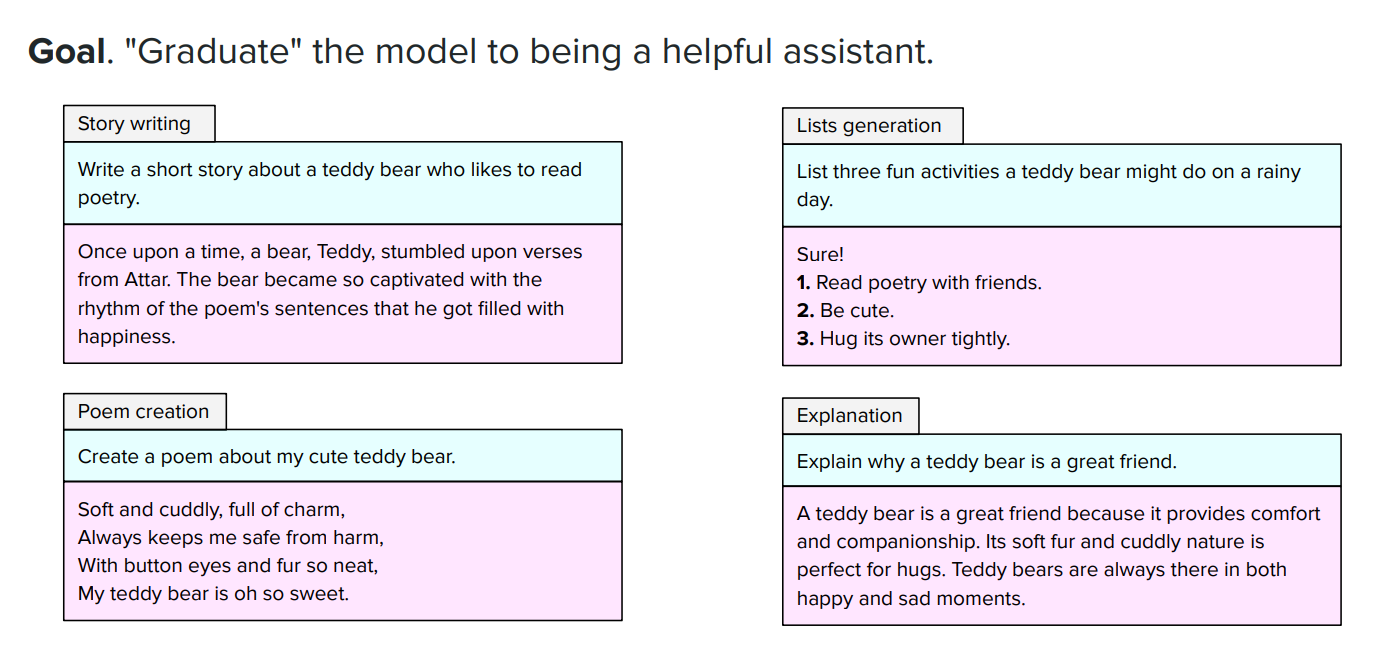

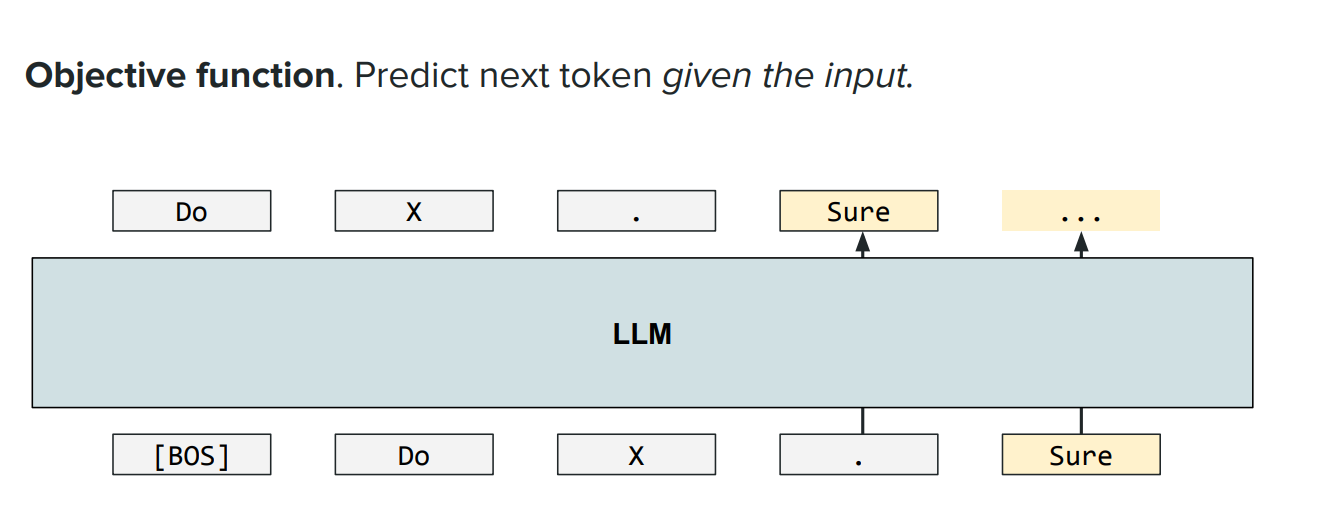


---

## Key Difference: Pre-training vs SFT Objective

### Pre-training
- Model predicts **every token**
- Includes the input itself

$$
\mathcal{L}_{\text{pretrain}} =
- \sum_{t=1}^{T}
\log P(x_t \mid x_1, \dots, x_{t-1})
$$

- Loss applies to **all tokens**
- Teacher forcing everywhere

---

### Supervised Fine-Tuning (SFT)

- Input is **conditioning context**
- No loss on input tokens
- Loss applies **only to output tokens**

Let:
- $( x $) = input (prompt)
- $( y = (y_1, \dots, y_N) $) = target output

$$
\mathcal{L}_{\text{SFT}} =
- \sum_{t=1}^{N}
\log P(y_t \mid x, y_1, \dots, y_{t-1})
$$

✅ Input is **given**  
✅ Model is trained to **respond**, not repeat

---

## Teacher Forcing in SFT

- Teacher forcing is used **only on output**
- The model:
  - Sees the full prompt
  - Predicts the response token-by-token
- Ground truth output tokens are provided during training

---

## Intuition Behind SFT

- Pre-training:  
  → *“What token usually comes next?”*

- SFT:  
  → *“Given this instruction, what is the best response?”*

This shifts the model from:
- Language modeling  
to  
- Instruction following

---

## Why SFT Works Well

- Uses **human-written answers**
- Teaches:
  - Helpfulness
  - Politeness
  - Structure
  - Safety-aware behavior
- Much cheaper than pre-training
- Strong performance gains

---

## Role of SFT in LLM Training Pipeline

1. **Pre-training**
   - Learn language & world patterns
2. **Supervised Fine-Tuning**
   - Learn how to respond
3. *(Next)* Alignment & preference optimization

---

## Key Takeaways
- SFT is **mandatory** for useful LLMs
- Input tokens are **not predicted**
- Loss is applied **only to outputs**
- Same next-token loss, different conditioning
- Turns LLM into an assistant


## Instruction Tuning (A Special Case of SFT)

### From Language Modeling → Helpful Assistant
- Pre-training:
  - Learns **how language looks**
  - Predicts likely next tokens
- Supervised Fine-Tuning (SFT):
  - Teaches **how to respond**
- **Instruction Tuning**:
  - Teaches the model to **follow instructions**

Instruction tuning is a **subcategory of SFT** focused specifically on:
- Answering user instructions
- Acting as an assistant

---

## Instruction Tuning Objective

Given:
- An **instruction** (input)
- A **desired response** (output)

The model is trained to:
- Condition on the instruction
- Predict only the response tokens

### Loss Application
- ❌ No loss on instruction tokens
- ✅ Loss applied only to response tokens

Illustration:

[ Instruction / Prompt ] → [ Response Tokens ]
↑
Loss computed here


---

## Instruction-Tuning Data Composition

Unlike pre-training (raw internet text), instruction tuning uses **curated data** that demonstrates *helpful behavior*.

### Common Instruction Categories
- Story writing
- Poem generation
- List creation
- Explanations
- Summarization
- Question answering
- Code generation
- Reasoning tasks
- Assistant-style dialogues

Each example is a **(instruction, ideal response)** pair.

---

## Assistant Dialogues

- Many SFT datasets are framed as **assistant conversations**
- User asks a question
- Assistant provides a helpful answer

This trains the model to:
- Be conversational
- Follow intent
- Produce coherent responses

---

## Human vs Synthetic Instruction Data

### Early Instruction Tuning
- Instructions written by humans
- Responses written by expert annotators
- High quality but **slow and expensive**

### Modern Instruction Tuning
- Use existing strong LLMs to:
  - Generate candidate responses
  - Augment datasets
- Humans or other models:
  - Review
  - Filter
  - Rank quality

This **scales instruction data creation** significantly.

---

## Safety-Oriented Instruction Data

Instruction tuning data also includes **safety-focused examples**.

### Purpose
- Ensure model is:
  - Helpful
  - Harmless
  - Responsible

### Examples
- Refusing harmful requests
- Avoiding dangerous instructions
- Hedging uncertain claims
- Rejecting disallowed content

Example behavior:

**`"I'm sorry, I can’t help with that request."`**


⚠️ This behavior is **learned**, not hard-coded via rules.

---

## Why Not Use Rules or Regex?
- Rule-based systems:
  - Not scalable
  - Fragile
- Instead:
  - Safety behavior is **embedded into model weights**
  - Learned through supervised examples

---

## Generalization From Instruction Tuning

Example:
- Dataset includes:
  - “Write a story”
- Prompt at inference:
  - “Write a sci-fi poem about space-time”

Why does this work?
- Pre-training:
  - Teaches what sci-fi, poems, space-time are
- Instruction tuning:
  - Teaches **how to follow instructions**

➡️ Model learns the *pattern*, not the exact content.

---

## Instruction Tuning Scale (Orders of Magnitude)

Instruction tuning uses **far less data** than pre-training.

### Reported Numbers
- GPT-3:
  - ~13,000 instruction examples
- LLaMA-3:
  - ~10 million instruction examples

### Rough Token Estimate
Assume:
- ~1,000 tokens per example

Then:
- SFT data ≪ Pre-training data
- Several **orders of magnitude smaller**

---

## Mental Model: Pre-training vs Instruction Tuning

| Stage | Data Size | Data Quality | Purpose |
|-----|----------|--------------|--------|
| Pre-training | Trillions of tokens | Noisy | Learn language |
| SFT / Instruction Tuning | Millions of examples | High-quality | Learn helpful behavior |

---

## Effect of Instruction Tuning (Teddy Bear Example)

**Before (Pre-trained model):**
- Continues text probabilistically
- Does not answer the question

**After Instruction Tuning:**
- Responds directly
- Gives helpful advice
- Aligns with user intent

Example:

**`"You should handwash the teddy bear instead of using a washer."`**


---

## Key Observation
- Instruction tuning **aligns model behavior**
- Makes LLMs usable by humans
- Still uses next-token prediction
- But with **task-aware conditioning**


## Challenges of Supervised Fine-Tuning (SFT) and Motivation for Optimization

### 1. High-Quality Data Requirement
- SFT requires **high-quality, curated data**
- “High-quality” usually implies:
  - Human involvement
  - Expert-written responses
  - Compliance with safety and policy rules
- Early SFT datasets were:
  - Almost entirely **human-generated**
  - Expensive in time, cost, and coordination

Modern pipelines:
- Mix **human-written** and **model-generated** data
- Still require:
  - Human review
  - Filtering
  - Quality control

✅ Advantage:
- Once created, datasets can be **reused and extended over time**

❌ Disadvantage:
- Still expensive in human and computational resources

---

### 2. Prompt Distribution Mismatch
- SFT data comes from a **specific prompt distribution**
- Real-world inference prompts may differ significantly

Example:
- Training prompt:
  - “Write a story”
- Inference prompt:
  - “Write a story inspired by a specific movie plot”

This creates an **out-of-distribution (OOD)** issue.

Key idea:
- Model generalization depends on:
  - Coverage of prompt space
  - Diversity of training examples

---

### 3. Memorization vs Generalization
- Question:
  - If we give the model a prompt identical to one seen during SFT, will it reproduce the same response?

Answer:
- Usually **no**, because:
  - Sampling is stochastic
  - Temperature > 0
- Output may:
  - Have the same *flavor*
  - But not the same wording

Influencing factors:
- Temperature
- Sampling strategy
- Pre-training diversity

---

### 4. Role of Temperature
- Higher temperature:
  - More diversity
  - More creative outputs
  - Higher chance of unlikely tokens
- Lower temperature:
  - More deterministic
  - Less variation

Temperature directly controls:
- How much the model explores the probability space

---

### 5. Improving Generalization
- Primary lever: **data**
- More diverse and sparse coverage of prompt space:
  - Better generalization
  - Less overfitting to specific examples
- Repeating similar examples ≠ better learning

Key idea:
- Teach the **concept**, not the exact instance

---

## Evaluation Challenges for Instruction-Tuned Models

### Why Evaluation Is Hard
- Helpfulness is **subjective**
- No single metric captures user satisfaction

---

### Benchmark-Based Evaluation

Common benchmark categories:
- General language understanding
- Reasoning
- Math
- Code generation

Examples:
- **MMLU** (Massive Multitask Language Understanding)
  - ~50 tasks
  - Single aggregate score
- **GSM8K**
  - Grade-school math reasoning
  - ~8K problems

---

### The “Training on the Test Task” Problem
Observed phenomenon:
- Sudden benchmark performance jumps
- Often unexplained by architecture changes

Cause:
- Model trained on **data resembling the benchmark task**

Important distinction:
- Training on the **test task**
- NOT necessarily training on the **test set**

Implication:
- Benchmark scores depend heavily on training mixture

⚠️ Fair comparison requires:
- Parity in training exposure
- Transparency about auxiliary data

---

### Benchmark Saturation
- Models optimize for known benchmarks
- New benchmarks appear to fill gaps
- Leads to:
  - Score inflation
  - Weak correlation with real-world usefulness

---

## Human Preference-Based Evaluation

### Chatbot Arena
- Users compare two model responses
- Choose preferred one
- Rankings computed via pairwise comparisons

Captures:
- “Vibes”
- User preference
- Conversational quality

---

### Limitations of Preference-Based Evaluation

1. **Early Noise Sensitivity**
   - Initial comparisons heavily influence rankings

2. **Leaderboard Manipulation Risk**
   - Models can detect:
     - Who they are being compared against
   - Adversarial behavior possible

3. **Factuality vs Helpfulness**
   - Users may prefer:
     - Detailed but incorrect answers
   - Users may lack domain knowledge to verify correctness

4. **Subjective Preferences**
   - Style preferences differ:
     - Emojis vs no emojis
     - Conciseness vs verbosity
   - Expert preferences ≠ general population preferences

5. **Safety Bias**
   - Users dislike refusals
   - Preference systems may favor unsafe compliance
   - Conflicts with intended safety policies

---

## No Single “Best” Metric
- Benchmarks → objective but narrow
- Human preference → subjective but broad
- Safety → policy-driven
- Real usefulness depends on **use case**

Evaluation must be:
- Multi-dimensional
- Context-aware
- Goal-driven

---

## Alignment: Where SFT Fits

### Alignment Definition
Alignment = making the model:
- Helpful
- Harmless
- Honest

### Alignment Stages
1. **Supervised Fine-Tuning (SFT)**
2. **Preference Tuning** (next lecture)

Together:
- Form the **alignment pipeline**

---

## Emerging Concept: Mid-Training

- Occurs **after pre-training**
- Uses the same next-token objective
- But on **task-relevant data**
- Bridges gap between:
  - General pre-training
  - Task-specific fine-tuning

Mid-training is:
- New
- Actively researched
- Increasingly adopted

---

## Big Picture (So Far)

1. Pre-training:
   - Learn language
2. SFT / Instruction Tuning:
   - Learn to help
3. Preference Tuning:
   - Learn what users prefer
4. Evaluation:
   - Hard, multi-faceted, imperfect




## Parameter-Efficient Fine-Tuning (PEFT): LoRA and QLoRA

### Motivation: Why PEFT?
- Full fine-tuning updates **all model parameters**
- Computationally expensive:
  - High memory usage
  - Large optimizer states
  - Long training time
- Goal:
  - Adapt large pre-trained models
  - While training **as few parameters as possible**

---

## LoRA: Low-Rank Adaptation

### Core Idea
- **Freeze** pre-trained weights
- Learn a **low-rank update** instead of full weight updates

---

### Standard Linear Layer
Given a linear transformation:
$$
y = W_0 x
$$

- $(W_0 \in \mathbb{R}^{d_{out} \times d_{in}}$)
- $(W_0$) is **pre-trained**

---

### LoRA Formulation
Instead of updating $(W_0$), we write:
$$
W = W_0 + \Delta W
$$

Where:
$$
\Delta W = B A
$$

- $(B \in \mathbb{R}^{d_{out} \times r}$)
- $(A \in \mathbb{R}^{r \times d_{in}}$)
- $(r \ll \min(d_{out}, d_{in})$)

---

### Forward Pass with LoRA
$$
y = W_0 x + B(Ax)
$$

- $(W_0$): **frozen**
- $(A, B$): **trainable**

---

### Parameter Reduction
- Full fine-tuning parameters:
$$
d_{out} \times d_{in}
$$

- LoRA parameters:
$$
r(d_{out} + d_{in})
$$

Example:
- $(d_{out}, d_{in} \sim 1000$)
- $(r \sim 4$) or $(8$)

➡️ **Orders of magnitude fewer trainable parameters**

---

### Task-Specific Adaptation
- $(W_0$): general language knowledge
- $(A, B$): task-specific adaptation

Example:
- Spam detection → one set of $(A, B$)
- Sentiment analysis → another set of $(A, B$)

Same base model, different LoRA adapters

---

## Where Is LoRA Applied?

### Original LoRA Paper
- Applied mainly to **attention projections**:
  - $(W_Q, W_K, W_V, W_O$)

---

### Later Findings
- Best performance gains from:
  - **Feed-Forward Networks (FFN / MLP blocks)**
- Modern practice:
  - Apply LoRA to:
    - Attention layers
    - Feed-forward layers
  - Majority of gains from FFN

---

## Practical Training Observations (Empirical)

### 1. Higher Learning Rate
- LoRA typically uses:
$$
\text{LR}_{\text{LoRA}} \approx 10 \times \text{LR}_{\text{full FT}}
$$

Hypothesis:
- Low-rank matrices explore a smaller subspace
- Need larger steps to adapt effectively

---

### 2. Large Batch Size Hurts
- LoRA performance degrades with very large batch sizes

Possible explanation:
- Training dynamics of **matrix products** differ from full matrices
- Gradient noise may help LoRA adaptation

⚠️ Empirical observation, not fully theoretically explained

---

### Rank Selection (Hyperparameter $(r$))
- Typical values:
  - $(r = 4, 8, 16$)
- Grid search possible but often unnecessary
- Popular defaults work well
- Parameter reduction already massive → diminishing returns beyond this

---

## QLoRA: Quantized LoRA

### Motivation
- Even frozen weights $(W_0$) consume VRAM
- Goal:
  - Quantize **frozen base model**
  - Train LoRA adapters in high precision

---

### QLoRA Setup
- $(W_0$): **Quantized**
- $(A, B$): **BF16 / FP16**
- Gradients only flow through LoRA weights

---

### NF4 Quantization
- NF4 = NormalFloat 4-bit
- Assumes weights follow a **normal distribution**
- Uses **quantiles**, not uniform buckets

Benefits:
- Better use of limited bits
- Lower quantization error

---

### Double Quantization
1. Quantize weights
2. Quantize quantization constants

Purpose:
- Further reduce memory overhead

---

### Memory Savings
- QLoRA achieves:
  - **~16× VRAM reduction**
- Double quantization:
  - Small additional gains

---

## Summary of LoRA vs QLoRA

| Method | Base Weights | Trainable Weights | Precision | Memory |
|------|-------------|------------------|-----------|--------|
| Full FT | Trainable | All | FP16/32 | ❌ Huge |
| LoRA | Frozen | A, B | FP16 | ✅ Low |
| QLoRA | Quantized | A, B | BF16 | ✅✅ Very Low |

---

## Key Takeaways
- LoRA enables efficient fine-tuning of LLMs
- Low-rank updates capture task-specific knowledge
- QLoRA makes fine-tuning possible on limited hardware
- Widely used in practice for LLM adaptation
